In [3]:
from core import altopt, plot_altopt
from core import DataContext, ParameterContext
import os
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from core import get_final_interpolator

In [5]:
DATA_DIR = r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_7"
DATASET3 = DataContext(
    sim_time = os.path.join(DATA_DIR, "t_array.csv"),
    sim_freq = os.path.join(DATA_DIR, "delz_MHz.csv"),
    sim_by = os.path.join(DATA_DIR, "dely_MHz.csv"),
    sim_intensities = sorted([
        os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.startswith("transH_t_vs_Bz_alpha2500_delx_0.01_dely_") and f.endswith(".csv")
    ], key=lambda x: float(x.split("_dely_")[1].split(".csv")[0])),
    exp_time = r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\70musData_CW\t_exp_70mus.csv",
    exp_freq_axis = r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\70musData_CW\Y_MHz.csv",
    exp_data = r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\70musData_CW\Prb_trans_Exp_70mus.csv",
    save_path = r"Results\Dataset_7\19_Mar\Test_1_Dataset_7_from_25_microseconds_0.1_step",
    interpolator=r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_7\gpu_sim_interpolator_new_normalisation_linear_0.3_threshold.npz",
    Aligned = False,
    sim_pulse_thresh=0.3,
    exp_pulse_thresh=0.3
)
DEFAULT_ALTOPT_PARAMS = ParameterContext(
    num_iter=10,
    curr_time = 25.0,
    max_time = 70.0,
    tol_bz=1e-20,
    tol_by=1e-20,
    t_step = 0.1,
    fixed_by_estimate=0.0,
    B_unk_bound_transverse_upper=0.4,
    fixed_bz_estimate=0.0,
    print_plot = False,
    Est_First_Z= False
)

In [6]:
Test = f"Dataset_7_Starting with {DEFAULT_ALTOPT_PARAMS.curr_time} us_T Step {DEFAULT_ALTOPT_PARAMS.t_step} us_arbitrary initial estimates"
DEFAULT_ALTOPT_PARAMS.Test = Test

In [ ]:
results = altopt(DATASET3, DEFAULT_ALTOPT_PARAMS)
plot_altopt(DATASET3, *results)
print(*results)

...Starting Adaptive Experiment for Y Estimation...
Loading Experiment from DataFiles_to_Dinesh_Pranav\Data_files\Experiment\70musData_CW\Prb_trans_Exp_70mus.csv...
  > Exp Start: 2.1100s
0.19577956199645996 was the time taken to load exp data.
...Building Final Interpolator...
Time taken to load Interpolator: 1.428755283355713
0.14307928085327148 was the time taken to compute the Transverse Likelihood calculation. | 
 T=25.1 | BiasZ=0.000 | Est By=0.09060 | Std=0.0268| Res=1.0e-04KL Calculation Time: 0.11369538307189941 0.003645658493041992 was the time taken to compute the Transverse Likelihood calculation. |   [ZOOM] Triggered! Mass concentrated in 393 points.| New Res: 9.09090909090909e-05 | Idx_01: 833 |Idx_99: 1226 | new_b_grid_gpu[idx_01]: 0.0833 | new_b_grid_gpu[idx_99]: 0.1226   [ZOOM] Res: 0.0001 -> 9.09090909090909e-05 | Grid Size: 4412| 0.06613683700561523 was the time taken to increase resolution. 
 T=25.2 | BiasZ=-0.268 | Est By=0.09860 | Std=0.0045| Res=9.1e-05KL Calcula

New Plotting 

1. I need to create a concatenated array containing all the means and std devs, and also need to give it a savepath, which is fine

In [ ]:
directory = r"Results\Dataset_7\19_Mar\Test_1_Dataset_7_from_25_microseconds_0.1_step\Test_2026_03_18"
result_longitudinal_list = sorted([
        os.path.join(directory, f) for f in os.listdir(directory) if f.startswith(r"longitudinal_estimation_results_Dataset_7_Starting with 25.0 us_T Step 0.1 us_arbitrary initial estimates_20260318") and f.endswith(r".npz")
    ], key=lambda x: float(x.split(r"_20260318_")[1].split(r".npz")[0]))
result_transverse_list = sorted([
        os.path.join(directory, f) for f in os.listdir(directory) if f.startswith(r"transverse_field_estimation_results_Dataset_7_Starting with 25.0 us_T Step 0.1 us_arbitrary initial estimates_20260318") and f.endswith(r".npz")
    ], key=lambda x: float(x.split(r"_20260318_")[1].split(r".npz")[0]))

longitudinal_estimation_results = [np.load(f) for f in result_longitudinal_list]
transverse_field_estimation_results = [np.load(f) for f in result_transverse_list]
print(len(longitudinal_estimation_results), len(transverse_field_estimation_results))

bz_full_traj = []
bz_final_estimate = []
by_full_traj = []
by_final_estimate = []
bz_full_std = []
by_full_std = []
iters_per_block = 0
save_path = directory
for i in range(len(longitudinal_estimation_results)):
    print(i)
    if i==0:
        iters_per_block = longitudinal_estimation_results[i]["est"].shape[0]
        print(f"Iters per block: {iters_per_block}")
    bz_full_std += list(longitudinal_estimation_results[i]["stddev"])
    bz_full_traj += list(longitudinal_estimation_results[i]["est"])
    bz_final_estimate.append(longitudinal_estimation_results[i]["est"][-1])
    by_full_std += list(transverse_field_estimation_results[i]["stddev"])
    by_full_traj += list(transverse_field_estimation_results[i]["est"])
    by_final_estimate.append(transverse_field_estimation_results[i]["est"][-1])

print(len(bz_full_traj), len(by_full_traj), len(bz_full_std), len(by_full_std))
bz_full_traj, bz_full_std, by_full_traj, by_full_std = np.array(bz_full_traj), np.array(bz_full_std), np.array(by_full_traj), np.array(by_full_std)   
    

10 11
0
Iters per block: 261
1
2
3
4
5
6
7
8
9
2610 2610 2610 2610


In [ ]:
def plot_intra_iteration_convergence(bz_full_traj, bz_full_std, bz_final_estimate, by_full_traj, by_full_std, by_final_estimate, iters_per_block, save_path=None):
    """
    Plots the continuous, intra-iteration evolution of the Bayesian estimates.
    
    Parameters:
    - bz_full_traj, bz_full_std: 1D numpy arrays of length (N_total_steps)
    - by_full_traj, by_full_std: 1D numpy arrays of length (N_total_steps)
    - iters_per_block: Integer (e.g., if you run 100 KL steps per alternating iteration)
    """
    
    # Create an artificial x-axis where 1 "unit" is a full Alternating Optimization block
    n_total_steps = len(bz_full_traj)
    x_axis = np.arange(n_total_steps) / iters_per_block
    num_blocks = int(np.ceil(n_total_steps / iters_per_block))
    
    plt.rcParams.update({'font.family': 'serif', 'font.size': 10})
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True, gridspec_kw={'hspace': 0.1})

    # Plot Bz
    ax1.plot(x_axis, bz_full_traj, color='#1f77b4', linewidth=1.5, label='Intra-iteration MAP')
    ax1.plot(range(1,num_blocks+1), bz_final_estimate, '--', color= "#487494",marker = 'o', markersize=4, label='Final Estimate')
    ax1.fill_between(x_axis, bz_full_traj - 5*bz_full_std, bz_full_traj + 5*bz_full_std, color='#1f77b4', alpha=0.3, label=r'$\pm 5\sigma$')
    # ax1.fill_between(x_axis, bz_full_traj - 3*bz_full_std, bz_full_traj + 3*bz_full_std, color='#1f77b4', alpha=0.1, label=r'$\pm 3\sigma$')
    ax1.set_ylabel(r'$B_z$ Estimate (MHz)')
    ax1.grid(True, linestyle=':', alpha=0.5)
    ax1.set_ylim(-1, 1)
    # ax1.autoscale(enable=True, axis='y', tight=True)
    ax1.legend(loc='upper right', framealpha=0.9, ncol=2)

    # Plot By
    ax2.plot(x_axis, by_full_traj, color='#d62728', linewidth=1.5, label='Intra-iteration MAP')
    ax2.plot(range(1,num_blocks+1), by_final_estimate, '--', color= "#487494",marker = 'o', markersize=4, label='Final Estimate')
    ax2.fill_between(x_axis, by_full_traj - 5*by_full_std, by_full_traj + 5*by_full_std, color='#d62728', alpha=0.3, label=r'$\pm 5\sigma$')
    # ax2.fill_between(x_axis, by_full_traj - 3*by_full_std, by_full_traj + 3*by_full_std, color='#d62728', alpha=0.1, label=r'$\pm 3\sigma$')
    ax2.set_ylabel(r'$B_y$ Estimate (MHz)')
    ax2.set_xlabel('Alternating Optimization Iteration')
    ax2.grid(True, linestyle=':', alpha=0.5)
    ax2.set_ylim(0, 0.4)
    # ax2.autoscale(enable=True, axis='y', tight=True)
    ax2.legend(loc='upper right', framealpha=0.9, ncol=2)

    # Formatting visual dividers
    num_blocks = int(np.ceil(n_total_steps / iters_per_block))
    for i in range(num_blocks + 1):
        ax1.axvline(i, color='black', linestyle='-')
        ax2.axvline(i, color='black', linestyle='-')
        
        '''# Optional: Shade the background to show which variable is actively updating
        if i < num_blocks:
            if i % 2 == 0:
                ax1.axvspan(i, i+1, color='#1f77b4', alpha=0.05) # Bz Active
            else:
                ax2.axvspan(i, i+1, color='#d62728', alpha=0.05) # By Active'''

    ax2.set_xlim(0, num_blocks)
    ax2.set_xticks(np.arange(num_blocks + 1))
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

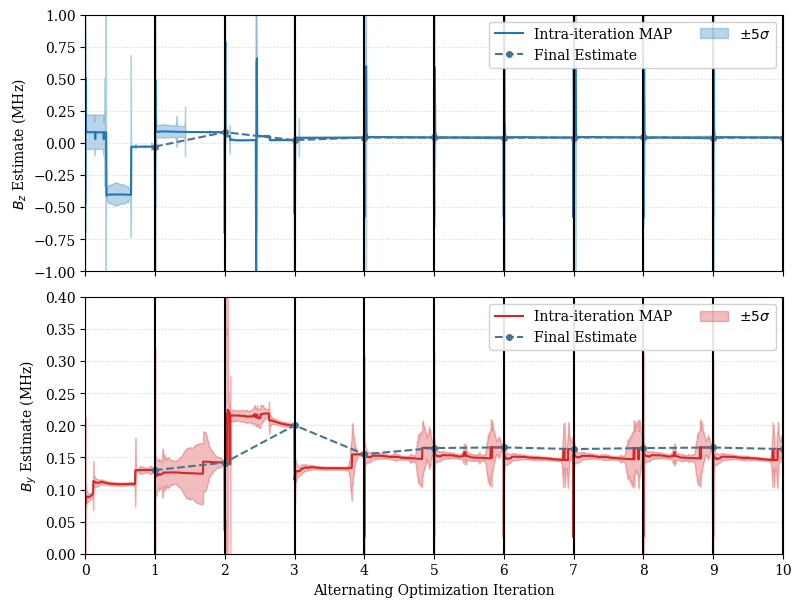

In [ ]:
plot_intra_iteration_convergence(bz_full_traj, bz_full_std, bz_final_estimate,by_full_traj, by_full_std, by_final_estimate, iters_per_block, save_path=os.path.join(save_path, "intra_iteration_convergence.png"))